# **Sufficiency of Ensemble Machine Learning Methods for Phishing Websites Detection**

*CY-3002 Vulnerability Assessment and Reverse Engineering*<br>
*Semester Project*

## **1. Objective:**
A phishing website is a common social engineering method that mimics trustful uniform resource locators (URLs) and webpages. The objective of this project is to develop and compare machine learning (ML) models and deep learning (DL) architectures for the detection of phishing websites. Leveraging a dataset consisting of both phishing and benign URLs, this research aims to extract relevant features from URLs and website content to train and evaluate various models. By implementing ML algorithms such as Random Forest and DL architectures including FCNN, LSTM, and CNN, the goal is to predict whether a given URL is likely to be associated with phishing activity or not. The performance of each model will be assessed in terms of accuracy, precision, recall, area under the curve (AUC), and training time to determine the most effective approach for phishing detection. 

## **2. Importing Neccessary Libraries:**
pandas and numpy are used for data handling, seaborn and matplotlib for data visualization, itertools for efficient looping, warnings to control warning messages, and time to track time for model training.

In [7]:
# Load essential Python libraries for data manipulation, visualization, and operations.
import pandas as pd                
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import warnings
import time

## **3. Importing Machine Learning Libraries:**
Metrics such as accuracy, precision, recall, and AUC are imported for performance evaluation. RandomForestClassifier is the chosen model for classification tasks.

In [8]:
# Importing machine learning tools from scikit-learn for model training, splitting data, and evaluating model performance.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

## **4. Importing Deep Learning Libraries:**
Sequential is used to stack layers linearly. Dense, LSTM, Dropout, Conv1D, and Flatten are different types of layers used in model architecture. Adam is an optimizer for training.

In [9]:
# Importing Keras libraries for building deep learning models including FCNN, LSTM and CNN.
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Conv1D, Flatten
from keras.optimizers import Adam

## **5. Importing Display Libraries:**
Display and HTML are used to render styled tables and HTML content. tabulate helps in creating ASCII tables.

In [10]:
# Importing libraries for displaying outputs in a structured and styled format within the Jupyter Notebook.
from IPython.display import display, HTML
from tabulate import tabulate

## **6. Suppressing Warnings:**
This prevents the display of warnings that might arise during model training or evaluation.

In [11]:
# Suppress warning messages to avoid clutter in the notebook output.
warnings.filterwarnings("ignore")

## **3. Loading Data:**

The dataset (.csv file) is loaded in this notebook and stored in the dataframe.

In [12]:
# Loading the data
data0 = pd.read_csv("urldata.csv")
data0.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


## **4. Familiarizing with Data:**

In this step, few dataframe methods are used to look into the data and its features.

In [13]:
# Checking the shape of the dataset
print("Data shape:", data0.shape)

Data shape: (10000, 18)


In [14]:
# #Listing the features of the dataset
print("Data columns:", data0.columns)

Data columns: Index(['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth',
       'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record',
       'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over',
       'Right_Click', 'Web_Forwards', 'Label'],
      dtype='object')


In [15]:
# Printing the information about the dataset including the data types and non-null counts.
print("Data information:", data0.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int64(17), object(1)
mem

## **5. Visualizing the data:**

In this section, plots and graphs are displayed to find how the data is distributed and the how features are related to each other.

Creating histograms to visualize the distribution of data across different features.

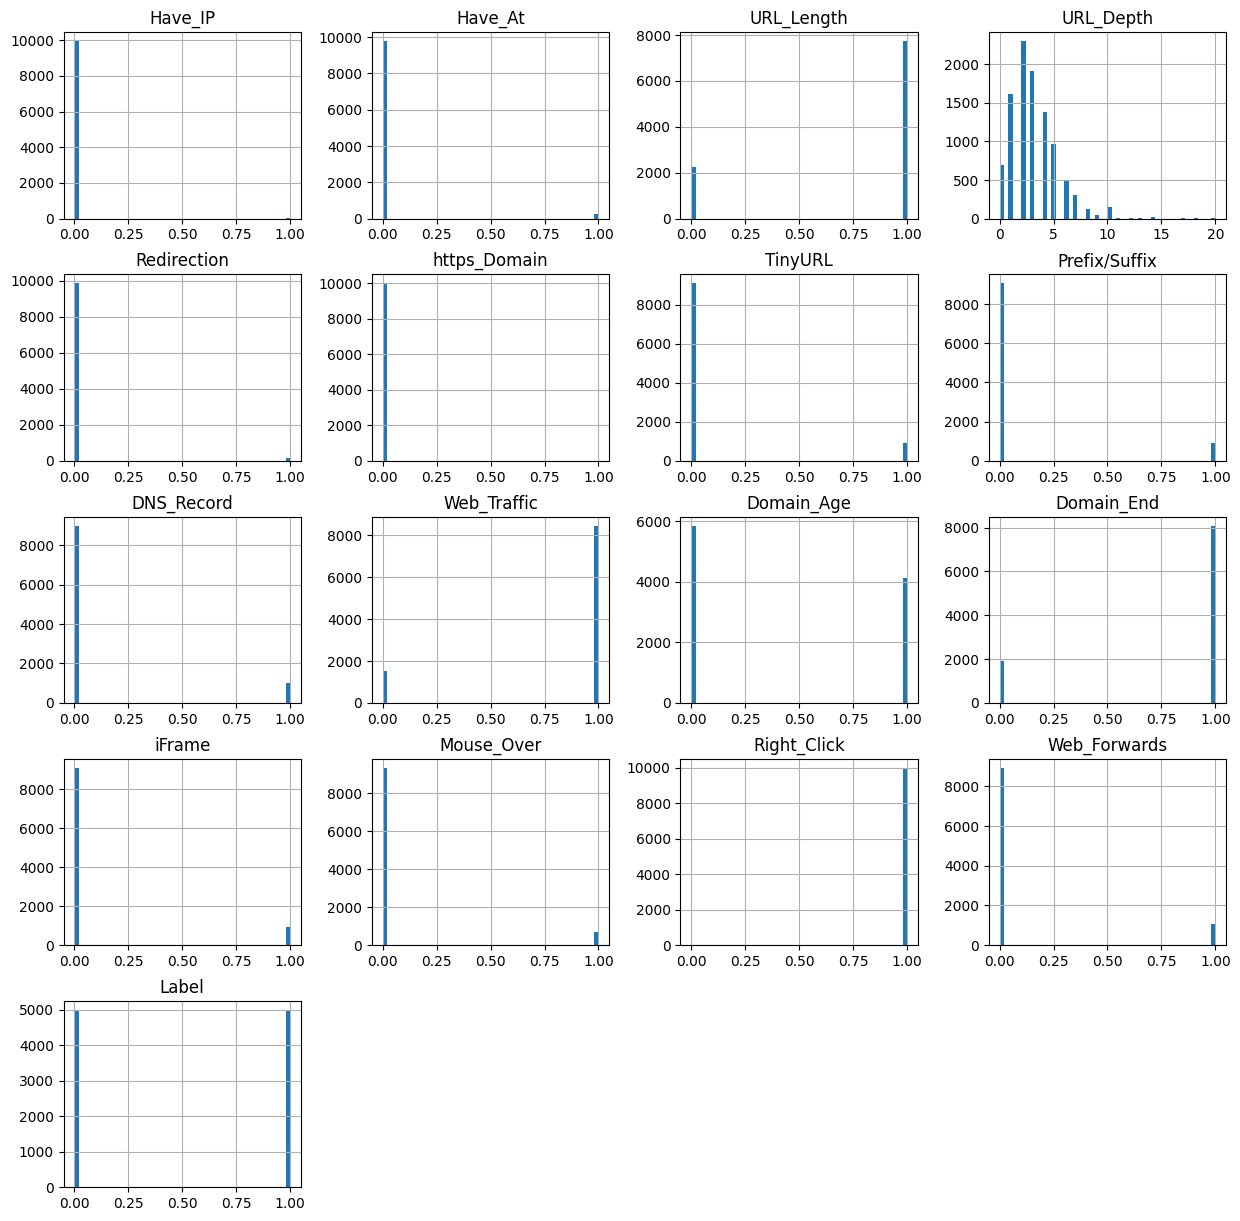

In [16]:
# Plotting the data distribution
data0.hist(bins=50, figsize=(15, 15))
plt.show()

Visualize the correlation between numerical features using a heatmap. <br>
The heatmap demonstrates the strength of correlation between features.

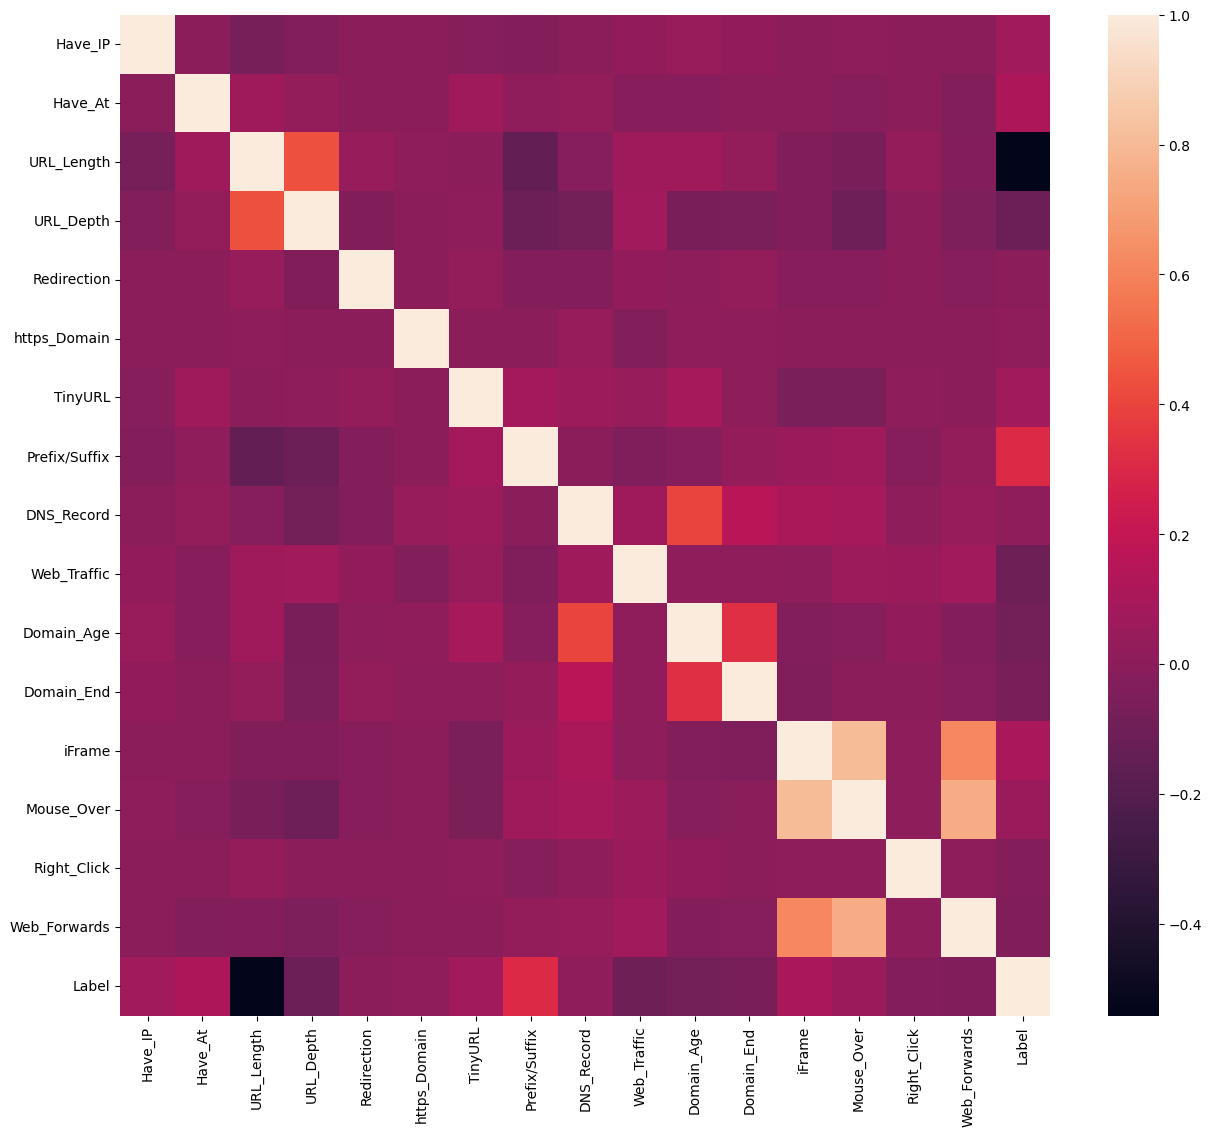

In [17]:
# Drop non-numeric columns
numeric_data = data0.select_dtypes(include=[np.number])

# Plot correlation heatmap
plt.figure(figsize=(15,13))
sns.heatmap(numeric_data.corr())
plt.show()

## **5. Data Preprocessing & EDA:**

In this section, the data is cleaned by applying data preprocesssing techniques. Then the data transformed to be useed in the models.

In [18]:
# Data Preprocessing & EDA
display(data0.describe())

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000
mean,0.005500,0.022600,0.773400,3.072000,0.013500,0.000200,0.090300,0.093200,0.100800,0.845700,0.413700,0.8099,0.090900,0.06660,0.99930,0.105300,0.500000
std,0.073961,0.148632,0.418653,2.128631,0.115408,0.014141,0.286625,0.290727,0.301079,0.361254,0.492521,0.3924,0.287481,0.24934,0.02645,0.306955,0.500025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.500000
75%,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0000,0.000000,0.00000,1.00000,0.000000,1.000000
max,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.00000,1.00000,1.000000,1.000000


The above obtained result shows that the most of the data is made of 0's & 1's except 'Domain' & 'URL_Depth' columns. <br> The Domain column doesnt have any significance to the machine learning model training. So dropping the 'Domain' column from the dataset.

In [19]:
# Dropping the Domain column
data = data0.drop(['Domain'], axis=1).copy()

This leaves us with 16 features & a target column. <br> The 'URL_Depth' maximum value is 20. <br> According to my understanding, there is no necessity to change this column.

In [20]:
# checking the data for null or missing values
data.isnull().sum()

Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Label            0
dtype: int64

In the feature extraction file, the extracted features of legitmate & phishing url datasets are just concatenated without any shuffling. <br>
This resulted in top 5000 rows of legitimate url data & bottom 5000 of phishing url data. <br>

To even out the distribution while splitting the data into training & testing sets, we need to shuffle it. <br>
This even evades the case of overfitting while model training. <br>

In [21]:
# shuffling the rows in the dataset so that when splitting the train and test set are equally distributed.
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,1
1,0,0,1,2,0,0,0,1,0,1,1,1,0,0,1,0,1
2,0,0,1,5,0,0,0,0,0,1,0,0,0,0,1,0,1
3,0,0,1,5,0,0,0,0,0,1,0,0,0,0,1,0,1
4,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0


From the above execution, it is clear that the data doesnot have any missing values.

By this, the data is throughly preprocessed & is ready for training.

## **6. Splitting the Data:**

In this section, features and Labels are separated features. Then the data is split into training and testing sets.

In [22]:
# Sepratating & assigning features and target columns to X & y
y = data['Label']
X = data.drop('Label',axis=1)
X.shape, y.shape

((10000, 16), (10000,))

In [23]:
# Splitting the dataset into train and test sets: 80-20 split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.2, random_state = 12)
X_train.shape, X_test.shape

((8000, 16), (2000, 16))

## **7. Model Training and Evaluation:**

From the dataset above, it is clear that this is a supervised learning. There are two major types of supervised learning problems, called classification and regression. 

This data set comes under classification problem, as the input URL is classified as phishing (1) or legitimate (0). The models considered to train the dataset for this project are:
* Random Forest (RF)
* AdaBoost
* GBDT
* HGB
* LightGBM

In [24]:
# Creating holders to store the model performance results
# Initializing lists to store model names and their training and testing accuracies.
ML_Model = []
acc_train = []
acc_test = []
precision = []
recall = []
f1 = []
training_time = []

In [25]:
# Function for storing results (stores the model’s name and its performance metrics)
def storeResults(model, train_acc, test_acc, prec, rec, f1_score, train_time):
    ML_Model.append(model)
    acc_train.append(round(train_acc, 3))
    acc_test.append(round(test_acc, 3))
    precision.append(round(prec, 3))
    recall.append(round(rec, 3))
    f1.append(round(f1_score, 3))  # Corrected variable name here
    training_time.append(round(train_time, 3))

### **7.1. Random Forest (RF)**
Random Forest is an ensemble learning method that constructs multiple decision trees during training and outputs the mode of the classes (classification) or the mean prediction (regression) of the individual trees. In the context of the research paper on phishing website detection, Random Forest is used as one of the machine learning models to classify URLs as either phishing or benign based on features extracted from the URLs.

In [26]:
# RandomForestClassifier is initialized with a random state of 42 to ensure reproducibility of results.
start = time.time()
rf_model = RandomForestClassifier(random_state=42)

# The model is trained on the training data (X_train, y_train) using the fit method.
rf_model.fit(X_train, y_train)

# The time taken for training (rf_train_time) is recorded using the time module.
end = time.time()
rf_train_time = end - start

In [27]:
# The trained model is used to predict the labels for both the training and testing data.
# Predictions for the training and testing sets are stored in rf_train_preds and rf_test_preds, respectively.
rf_train_preds = rf_model.predict(X_train)
rf_test_preds = rf_model.predict(X_test)

In [28]:
# Performance metrics such as accuracy, precision, recall, and F1 score are calculated using the predicted labels and actual labels.
rf_train_accuracy = accuracy_score(y_train, rf_train_preds)
rf_test_accuracy = accuracy_score(y_test, rf_test_preds)

rf_precision = precision_score(y_test, rf_test_preds)
rf_recall = recall_score(y_test, rf_test_preds)
rf_f1_score = f1_score(y_test, rf_test_preds)

In [29]:
# These metrics are then stored along with the training time using the storeResults function.
storeResults("Random Forest", rf_train_accuracy, rf_test_accuracy, rf_precision, rf_recall, rf_f1_score, rf_train_time)

# Printing the training and testing accuracies of the Random Forest model for analysis.
print(f"\nTraining Accuracy of Random Forest: {rf_train_accuracy}")
print(f"Test Accuracy of Random Forest: {rf_test_accuracy}\n")


Training Accuracy of Random Forest: 0.867875
Test Accuracy of Random Forest: 0.859



### **7.2. AdaBoost (Adaptive Boosting)**
AdaBoost (Adaptive Boosting) is an ensemble learning method that combines multiple weak learners to create a strong classifier. In the context of the research paper on phishing website detection, AdaBoost is utilized as a machine learning model to classify URLs as either phishing or benign based on the features extracted from the URLs.

In [30]:
# AdaBoostClassifier is initialized with a random state of 42 to ensure reproducibility of results.
start = time.time()
adaboost_model = AdaBoostClassifier(random_state=42)

# The model is trained on the training data (X_train, y_train) using the fit method.
adaboost_model.fit(X_train, y_train)

# The time taken for training (adaboost_train_time) is recorded using the time module.
end = time.time()
adaboost_train_time = end - start

In [31]:
# The trained model is used to predict the labels for both the training and testing data
adaboost_train_preds = adaboost_model.predict(X_train)
adaboost_test_preds = adaboost_model.predict(X_test)

# # Predictions for the training and testing sets are stored in adaboost_train_preds and adaboost_test_preds, respectively.
adaboost_train_accuracy = accuracy_score(y_train, adaboost_train_preds)
adaboost_test_accuracy = accuracy_score(y_test, adaboost_test_preds)

In [32]:
# Performance metrics such as accuracy, precision, recall, and F1 score are calculated using the predicted labels and actual labels.
adaboost_precision = precision_score(y_test, adaboost_test_preds)
adaboost_recall = recall_score(y_test, adaboost_test_preds)
adaboost_f1_score = f1_score(y_test, adaboost_test_preds)

In [33]:
# These metrics are then stored along with the training time using the storeResults function.
storeResults("AdaBoost", adaboost_train_accuracy, adaboost_test_accuracy, adaboost_precision, adaboost_recall, adaboost_f1_score, adaboost_train_time)

# Printing the training and testing accuracies of the AdaBoost model for analysis.
print(f"\nTraining Accuracy of AdaBoost: {adaboost_train_accuracy}")
print(f"Test Accuracy of AdaBoost: {adaboost_test_accuracy}\n")


Training Accuracy of AdaBoost: 0.810125
Test Accuracy of AdaBoost: 0.8075



### **7.3. Gradient Boosting Decision Tree (GBDT)**
Gradient Boosting Decision Tree (GBDT) is another ensemble learning technique used for classification tasks. It builds multiple decision trees sequentially, where each subsequent tree corrects the errors made by the previous one. In the context of the research paper on phishing website detection, GBDT is employed as a machine learning model to classify URLs as either phishing or benign based on the features extracted from the URLs.

In [34]:
# The GradientBoostingClassifier is initialized with a random state of 42 to ensure reproducibility of results.
start = time.time()
gbdt_model = GradientBoostingClassifier(random_state=42)

# The model is trained on the training data (X_train, y_train) using the fit method.
gbdt_model.fit(X_train, y_train)

# The time taken for training (gbdt_train_time) is recorded using the time module.
end = time.time()
gbdt_train_time = end - start

In [35]:
# The trained model is used to predict the labels for both the training and testing data.
# Predictions for the training and testing sets are stored in gbdt_train_preds and gbdt_test_preds, respectively.
gbdt_train_preds = gbdt_model.predict(X_train)
gbdt_test_preds = gbdt_model.predict(X_test)

gbdt_train_accuracy = accuracy_score(y_train, gbdt_train_preds)
gbdt_test_accuracy = accuracy_score(y_test, gbdt_test_preds)

In [36]:
# Performance metrics such as accuracy, precision, recall, and F1 score are calculated using the predicted labels and actual labels.
gbdt_precision = precision_score(y_test, gbdt_test_preds)
gbdt_recall = recall_score(y_test, gbdt_test_preds)
gbdt_f1_score = f1_score(y_test, gbdt_test_preds)

In [37]:
# # These metrics are then stored along with the training time using the storeResults function.
storeResults("GBDT", gbdt_train_accuracy, gbdt_test_accuracy, gbdt_precision, gbdt_recall, gbdt_f1_score, gbdt_train_time)

# Printing the training and testing accuracies of the GBDT model for analysis.
print(f"\nTraining Accuracy of GBDT: {gbdt_train_accuracy}")
print(f"Test Accuracy of GBDT: {gbdt_test_accuracy}\n")


Training Accuracy of GBDT: 0.83475
Test Accuracy of GBDT: 0.8285



### **7.4. Histogram Gradient Boosting (HGB)**
Histogram Gradient Boosting (HGB) is a variant of gradient boosting methods that uses histograms to efficiently construct decision trees during training. In the context of the research paper on phishing website detection, HGB is employed as a machine learning model to classify URLs as either phishing or benign based on the features extracted from the URLs.

In [38]:
# The HistGradientBoostingClassifier is initialized with a random state of 42 to ensure reproducibility of results.
start = time.time()
hgb_model = HistGradientBoostingClassifier(random_state=42)

# The model is trained on the training data (X_train, y_train) using the fit method.
hgb_model.fit(X_train, y_train)

# The time taken for training (hgb_train_time) is recorded using the time module.
end = time.time()
hgb_train_time = end - start

  File "C:\Users\malik\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [39]:
# The trained model is used to predict the labels for both the training and testing data.
# Predictions for the training and testing sets are stored in hgb_train_preds and hgb_test_preds, respectively.
hgb_train_preds = hgb_model.predict(X_train)
hgb_test_preds = hgb_model.predict(X_test)

hgb_train_accuracy = accuracy_score(y_train, hgb_train_preds)
hgb_test_accuracy = accuracy_score(y_test, hgb_test_preds)

In [40]:
# Performance metrics such as accuracy, precision, recall, and F1 score are calculated using the predicted labels and actual labels.
hgb_precision = precision_score(y_test, hgb_test_preds)
hgb_recall = recall_score(y_test, hgb_test_preds)
hgb_f1_score = f1_score(y_test, hgb_test_preds)

# These metrics are then stored along with the training time using the storeResults function.
storeResults("HGB", hgb_train_accuracy, hgb_test_accuracy, hgb_precision, hgb_recall, hgb_f1_score, hgb_train_time)

# Printing the training and testing accuracies of the HGB model for analysis.
print(f"\nTraining Accuracy of HGB: {hgb_train_accuracy}")
print(f"Test Accuracy of HGB: {hgb_test_accuracy}\n")


Training Accuracy of HGB: 0.863625
Test Accuracy of HGB: 0.8575



### **7.5. LightGBM**
LightGBM (Light Gradient Boosting Machine) is a gradient boosting framework developed by Microsoft that uses tree-based learning algorithms. In the context of the research paper on phishing website detection, LightGBM is employed as a machine learning model to classify URLs as either phishing or benign based on the features extracted from the URLs.

In [41]:
# The LGBMClassifier is initialized with a random state of 42 and verbose set to -1 for minimal output.
start = time.time()
lgbm_model = LGBMClassifier(random_state=42, verbose=-1)

# The model is trained on the training data (X_train, y_train) using the fit method.
lgbm_model.fit(X_train, y_train)

# The time taken for training (lgbm_train_time) is recorded using the time module.
end = time.time()
lgbm_train_time = end - start

In [42]:
# The trained model is used to predict the labels for both the training and testing data.
# Predictions for the training and testing sets are stored in lgbm_train_preds and lgbm_test_preds, respectively.
lgbm_train_preds = lgbm_model.predict(X_train)
lgbm_test_preds = lgbm_model.predict(X_test)

lgbm_train_accuracy = accuracy_score(y_train, lgbm_train_preds)
lgbm_test_accuracy = accuracy_score(y_test, lgbm_test_preds)

In [43]:
# Performance metrics such as accuracy, precision, recall, and F1 score are calculated using the predicted labels and actual labels.
lgbm_precision = precision_score(y_test, lgbm_test_preds)
lgbm_recall = recall_score(y_test, lgbm_test_preds)
lgbm_f1_score = f1_score(y_test, lgbm_test_preds)

In [44]:
# These metrics are then stored along with the training time using the storeResults function.
storeResults("LightGBM", lgbm_train_accuracy, lgbm_test_accuracy, lgbm_precision, lgbm_recall, lgbm_f1_score, lgbm_train_time)

# # Printing the training and testing accuracies of the LightGBM model for analysis.
print(f"\nTraining Accuracy of LightGBM: {lgbm_train_accuracy}")
print(f"Test Accuracy of LightGBM: {lgbm_test_accuracy}\n")


Training Accuracy of LightGBM: 0.8655
Test Accuracy of LightGBM: 0.8605



### **8. Creating Metrics Table:**
The purpose of creating the metrics_table DataFrame is to organize and summarize the performance metrics obtained from different machine learning models trained and evaluated for phishing website detection.

A dataframe is initailized. A pandas DataFrame named metrics_table is created.
It consists of the following columns:
* Model: Names of the machine learning models used.
* Training Time Cost (s): Time taken for training each model in seconds.
* Precision (%): Precision scores for each model.
* Recall (%): Recall scores for each model.
* F1 Score (%): F1 scores for each model.
* Accuracy (%): Accuracy scores for each model.

The values for each column are populated using the lists:
* ML_Model: Contains the names of the machine learning models.
* training_time: Contains the time taken for training each model.
* precision: Contains the precision scores for each model.
* recall: Contains the recall scores for each model.
* f1: Contains the F1 scores for each model.
* acc_test: Contains the accuracy scores for each model.

DataFrame Construction:
* Using the pd.DataFrame constructor, the data from the lists is organized into a tabular format, with each row representing a different model and each column representing a different metric. <br>

In [45]:
metrics_table = pd.DataFrame({
    'Model': ML_Model,
    'Training Time Cost (s)': training_time,
    'Precision (%)': precision,
    'Recall (%)': recall,
    'F1 Score (%)': f1,
    'Accuracy (%)': acc_test
})

### **9. Comparison of Models**
The main purpose of the following section is to compare the performance of all the models. The visual presentation of the performance metrics table (metrics_table) is enhanced by applying styling attributes to improve readability and aesthetics.

In [46]:
# Apply styling to the DataFrame
styled_metrics_table = metrics_table.style.set_properties(**{
    'text-align': 'right',
    'border-color': 'black',
    'border-style': 'solid',
    'border-width': '1px',
    'height': '25px'  # Sets a uniform row height
}).set_table_styles([
    {'selector': 'th',
     'props': [('font-weight', 'bold'),
               ('text-align', 'right'),
               ('background-color', '#FFD580'),  # Light warm color for header
               ('height', '35px')]},  # Sets a distinct height for the header row
    {'selector': 'td',
     'props': [('text-align', 'center'),
               ('background-color', '#FFF2CC')]},  # Light warm color for cells
]).hide(axis='index')  # Hides the index column

# Equal column width is set by dividing 100% by the number of columns
col_width = f"{100 / len(metrics_table.columns):.2f}%"
styled_metrics_table.set_table_styles([{
    'selector': '.col_heading',
    'props': [('width', col_width)]
}, {
    'selector': 'td',
    'props': [('width', col_width)]
}])

# Display the styled DataFrame
display(styled_metrics_table)

Model,Training Time Cost (s),Precision (%),Recall (%),F1 Score (%),Accuracy (%)
Random Forest,0.315000,0.954000,0.754000,0.842000,0.859000
AdaBoost,0.211000,0.865000,0.729000,0.791000,0.807000
GBDT,0.355000,0.959000,0.686000,0.800000,0.829000
HGB,0.452000,0.940000,0.764000,0.843000,0.858000
LightGBM,0.087000,0.941000,0.769000,0.846000,0.861000


### **10. Plotting Model Performance Metrics**
The purpose of this code is to visualize and compare the performance metrics (Accuracy, Precision, Recall, F1 Score) of different machine learning models used for phishing website detection. The visualization is presented as a set of bar plots, each representing a specific metric.

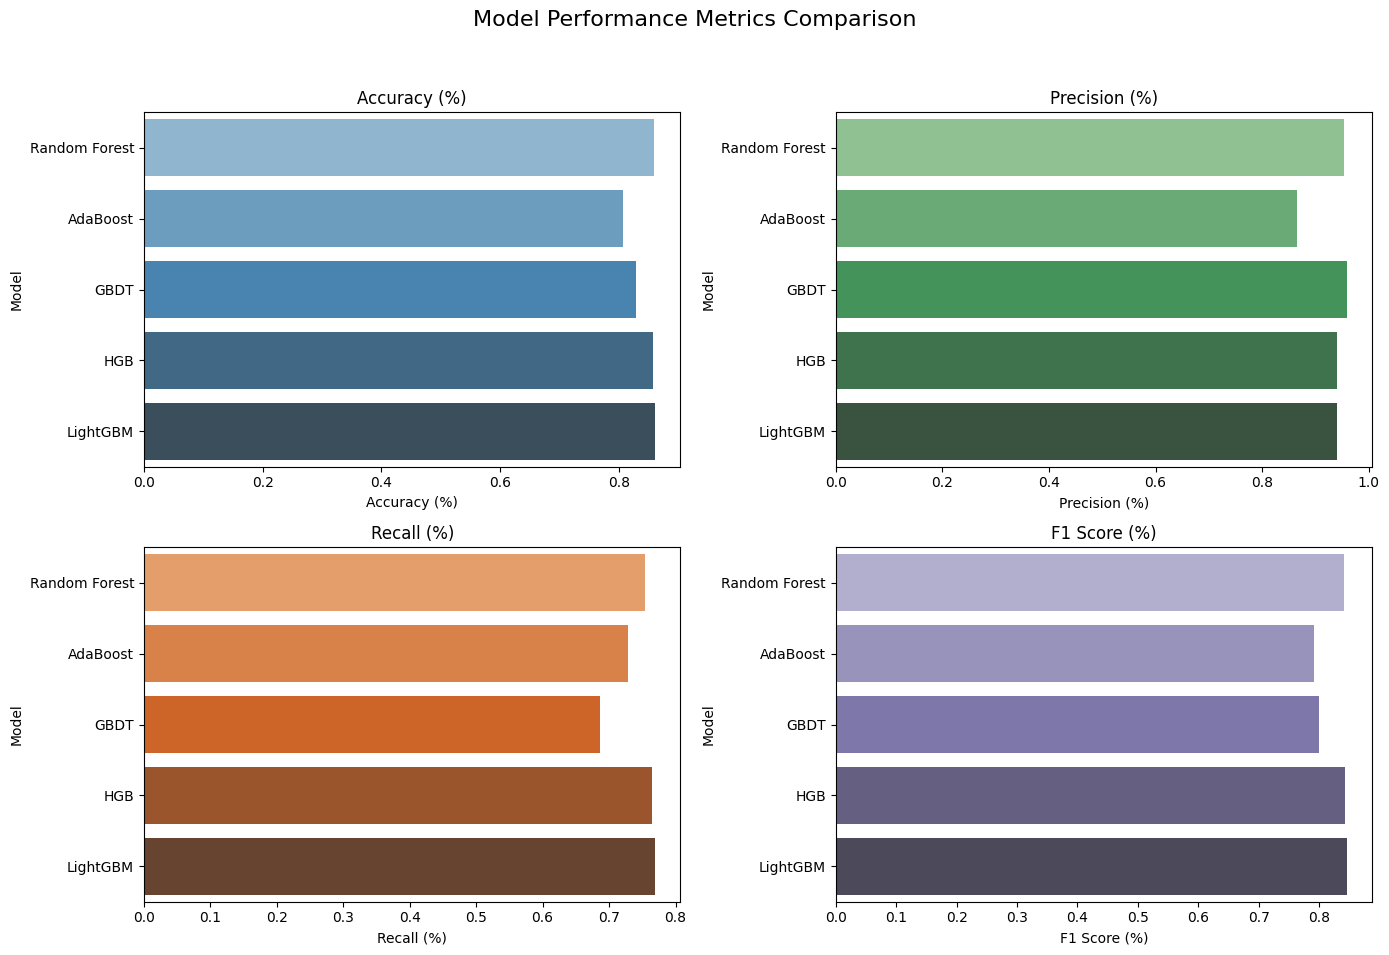

In [47]:
# Set up the matplotlib figure
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Model Performance Metrics Comparison', fontsize=16)

# Define a list of palettes for different subplots
palettes = ['Blues_d', 'Greens_d', 'Oranges_d', 'Purples_d']

# Plot Accuracy with blue palette
sns.barplot(x='Accuracy (%)', y='Model', data=metrics_table, ax=axes[0, 0], palette=palettes[0])
axes[0, 0].set_title('Accuracy (%)')

# Plot Precision with green palette
sns.barplot(x='Precision (%)', y='Model', data=metrics_table, ax=axes[0, 1], palette=palettes[1])
axes[0, 1].set_title('Precision (%)')

# Plot Recall with orange palette
sns.barplot(x='Recall (%)', y='Model', data=metrics_table, ax=axes[1, 0], palette=palettes[2])
axes[1, 0].set_title('Recall (%)')

# Plot F1 Score with purple palette
sns.barplot(x='F1 Score (%)', y='Model', data=metrics_table, ax=axes[1, 1], palette=palettes[3])
axes[1, 1].set_title('F1 Score (%)')

# Fine-tune the subplot layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Display the plots
plt.show()
